# 03b — Phase 2: shoreline EXTRACTION (run often)

Extracts sub-pixel shorelines using classifiers **loaded from Google Drive**. This
notebook **never trains** — there is no reachable `train_classifier`/`train_group`
call. If a needed model is missing it tells you to run **Notebook 03a**; it does
not train a fallback.

Thin driver of `src/extract.py`. Memory is bounded: `classify_scene` runs in row
blocks, `extract_all` frees each scene (+ `gc`) and prints per-scene peak RAM, so
the 829-scene Series B batch stays flat and under Colab's ~12 GB.

**Order:** mount Drive → build scene lists → load classifiers → build/load
transects → single-scene envelope QC → batch extract (Series A, then B) →
benchmark.

## Setup — clone-or-pull, authenticate GEE, import & reload `src/`

In [10]:
import os
REPO_DIR = '/content/Shoreline-Dynamics'
# Clone-or-pull so Colab always runs the latest committed code.
if os.path.isdir(REPO_DIR):
    !cd {REPO_DIR} && git pull -q
else:
    !git clone https://github.com/SKPrince1911/Shoreline-Dynamics.git {REPO_DIR}
%cd {REPO_DIR}
!pip install -q -r requirements.txt

/content/Shoreline-Dynamics


In [11]:
import ee, geemap
ee.Authenticate()
ee.Initialize(project='shoreline-analysis')
print('GEE initialized:', ee.String('ok').getInfo())

GEE initialized: ok


In [12]:
import sys; sys.path.append('.')
import importlib
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from src import config, data, extract
# Pick up freshly pulled modules without a kernel restart (config before its
# dependents). extract is on the reload list so edits to src/extract.py land.
importlib.reload(config); importlib.reload(data); importlib.reload(extract)

aoi = ee.Geometry.Polygon(config.aoi_coordinates())
print('feature dim:', extract.feats_dim(),
      '| default index:', config.WATER_INDEX_DEFAULT,
      '| threshold:', config.THRESHOLD_METHOD_DEFAULT)
print('sensor groups:', extract.SENSOR_GROUP)

feature dim: 20 | default index: mndwi | threshold: otsu
sensor groups: {'L4': 'TM', 'L5': 'TM', 'L7': 'TM', 'L8': 'OLI', 'L9': 'OLI', 'S2': 'MSI'}


## Mount Google Drive

Mount Drive so trained classifiers and exports read from / write to
`/content/drive/MyDrive/shoreline_dynamics/` and **survive a runtime restart**.
Skip only if you deliberately want everything under the (wiped-on-restart) repo
`models/`/`outputs/`.

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Scene list — Series A (annual)

Series A explodes the approved inventory into one row per **acquisition date**
(same-overpass granules mosaicked; multi-date composites split), so every scene
keeps its own timestamp for Phase 3.

In [14]:
# Cached to Drive (then local outputs/); rebuilt from the inventory if absent — fast.
annual = extract.get_scene_list_annual()
n_years = annual['dry_year'].nunique()
print(f'Series A: {len(annual)} scenes across {n_years} dry-season-years')
assert n_years == 38, f'expected 38 non-gap years, got {n_years}'
assert annual['acq_datetime_utc'].notna().all(), 'found a NaT timestamp!'
print('sensors:', annual['sensor'].value_counts().to_dict())

Series A: 60 scenes across 38 dry-season-years
sensors: {'L5': 35, 'L7': 10, 'S2': 8, 'L8': 6, 'L9': 1}


## Scene list — Series B (dense, all-season)  — **cached**

The dense query hits Earth Engine for hundreds of scenes and is **slow** (tens of
minutes to ~2 hours). `get_scene_list_dense()` **loads the cached
`scene_list_dense.csv` from Drive (then local `outputs/`) in seconds** and only
re-queries EE when the cache is missing/invalid or `FORCE_REBUILD_DENSE=True`. So
you build it **once**, it lives on Drive, and every future session loads instantly.
Needed before the Series B batch (not for the single-scene QC).

In [ ]:
FORCE_REBUILD_DENSE = False   # <-- True to re-query EE even if a cached list exists
# Loads from Drive cache in seconds; only queries EE (slow) when missing/invalid or forced.
dense = extract.get_scene_list_dense(force_rebuild=FORCE_REBUILD_DENSE)
print(f'Series B: {len(dense)} scenes | per sensor:', dense['sensor'].value_counts().to_dict())
incomplete = sorted(dense.loc[~dense['season_complete'].astype(bool), 'dry_year'].unique().tolist())
print('season_complete=False dry_years (exclude from per-year seasonal stats):', incomplete)

## Fetch / visual-QC helpers

In [15]:
from shapely.geometry import box
demo_ll = box(92.00, 21.33, 92.06, 21.42)     # (minlon, minlat, maxlon, maxlat)
demo_utm = extract._to_utm(demo_ll)

def rgb_from_scene(sc, pmin=2, pmax=98):
    # Per-scene 2-98% contrast stretch on the VALID pixels (a fixed 0..0.3 stretch
    # looks flat on turbid GBM water). Invalid pixels -> black.
    rgb = np.dstack([sc.bands['red'], sc.bands['green'], sc.bands['blue']]).astype('float32')
    fin = np.isfinite(rgb).all(axis=2)
    if fin.any():
        lo, hi = np.nanpercentile(rgb[fin], [pmin, pmax])
        if not (hi > lo):
            lo, hi = 0.0, 0.3
    else:
        lo, hi = 0.0, 0.3
    return np.nan_to_num(np.clip((rgb - lo) / (hi - lo), 0, 1), nan=0.0)

def show_scene(sc, title=''):
    fig, ax = plt.subplots(1, 2, figsize=(13, 6))
    ax[0].imshow(rgb_from_scene(sc)); ax[0].set_title(title + ' — true colour (2-98%)')
    ax[0].axis('off')
    ax[1].imshow(sc.valid.astype(float), cmap='gray', vmin=0, vmax=1)
    ax[1].set_title('valid mask (white = usable)'); ax[1].axis('off')
    plt.tight_layout(); plt.show()
    print(title, sc.sensor, sc.image_id[:44], '| acq', sc.acq_datetime_utc,
          '| georef', sc.georef_rmse_m, 'm | valid %.1f%%' % (100 * sc.valid.mean()))

def row_for(df, sensor=None, dry_year=None):
    q = df
    if sensor is not None: q = q[q['sensor'] == sensor]
    if dry_year is not None: q = q[q['dry_year'] == dry_year]
    return q.iloc[0] if len(q) else None

def first_covering(df, window_ll, sensor=None, dry_year=None):
    # First scene whose granule footprint intersects window_ll (a single Landsat
    # scene images only part of the AOI: WRS-2 paths 135 & 136).
    q = df
    if sensor is not None: q = q[q['sensor'] == sensor]
    if dry_year is not None: q = q[q['dry_year'] == dry_year]
    minx, miny, maxx, maxy = window_ll.bounds
    win = ee.Geometry.Rectangle([minx, miny, maxx, maxy])
    for _, r in q.iterrows():
        gid = str(r['image_id']).split(',')[0]
        if ee.Image(extract._ee_asset_id(gid, r['sensor'])).geometry().intersects(win, 1).getInfo():
            return r
    print('no', sensor or '', 'scene intersects the demo window — skipping')
    return None

## Load classifiers from Drive (never trains)

Loads the classifier for every sensor group Series A needs (TM/OLI/MSI) from Drive
(then local). A **missing** model is reported with a pointer to Notebook 03a — this
notebook does not train.

In [16]:
needed = sorted({extract.sensor_group(s) for s in annual['sensor'].unique()})
classifiers, missing = {}, []
for g in needed:
    if extract.model_exists(g):
        classifiers[g] = extract.load_classifier(g)   # prints the Drive/local path
    else:
        missing.append(g)
        print(f'MISSING model for group {g!r} -> run Notebook 03a to train it.')
print('loaded groups:', sorted(classifiers), '| missing:', missing)

loaded classifier <- /content/drive/MyDrive/shoreline_dynamics/models/clf_MSI_v1.joblib
MISSING model for group 'OLI' -> run Notebook 03a to train it.
MISSING model for group 'TM' -> run Notebook 03a to train it.
loaded groups: ['MSI'] | missing: ['OLI', 'TM']


## Transects (cached) — for the seaward envelope + benchmark

Built from `data/baseline.geojson` and cached to `outputs/transects.geojson`;
`_load_or_build_transects` rebuilds only when the baseline is newer. Envelope mode
needs these — without a baseline, extraction falls back to `raw`.

In [17]:
if os.path.exists(extract.BASELINE_PATH):
    transects = extract.build_transects()   # writes/refreshes outputs/transects.geojson
    print(f'built {len(transects)} transects @ {int(extract.TRANSECT_SPACING_M)} m spacing, '
          f'{int(extract.TRANSECT_LENGTH_M)} m long -> {extract.TRANSECTS_PATH}')
else:
    print('no', extract.BASELINE_PATH, '- envelope will fall back to raw (see 03a artifacts).')

built 1837 transects @ 50 m spacing, 1500 m long -> outputs/transects.geojson


## Single-scene envelope extraction + visual QC

`config.SHORELINE_MODE` (one-line flip): `'envelope'` (default) reduces the merged
contour to the **seaward-most** land/water boundary at each transect; `'raw'` keeps
the full-density sub-pixel line. The contour is traced across the **sand↔water
interface only** (`interface_mask`), so the landward sand/vegetation edge can't make
a false shoreline. The `seaward_methods` print should show **watermask > 90%**.

shoreline mode: envelope | transects: True
interface Otsu threshold: 0.3237 | contour segments: 57 | shoreline length_m: 95381.8
seaward: watermask=1761 (96.9%) baseline_normal=57 land_is_east=0 | fb no_water=57 no_sand=0 tie=0 no_labels=0 | n_multi=61


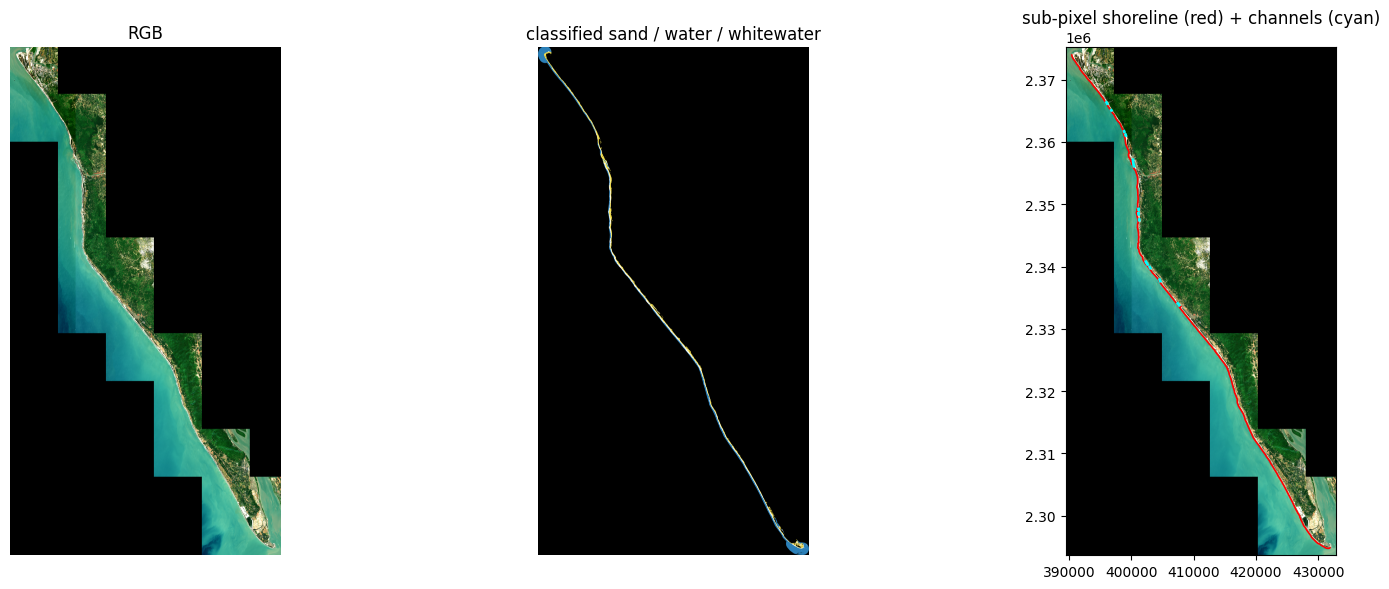

In [18]:
config.SHORELINE_MODE = 'envelope'   # <-- flip to 'raw' for the full sub-pixel cartographic line
if 'MSI' not in classifiers:
    print('BLOCKED: MSI model not loaded — run Notebook 03a to train it.')
    line = None
else:
    settings = extract.default_settings(water_index_name='mndwi', threshold_method='otsu')
    print('shoreline mode:', settings['mode'], '| transects:', settings['transects'] is not None)
    # first_covering returns a pandas Series or None -> None-check, never `or`
    # (bool(Series) raises "truth value is ambiguous").
    s2_row = first_covering(annual, demo_ll, sensor='S2', dry_year=2023)
    if s2_row is None:
        s2_row = row_for(annual, sensor='S2', dry_year=2023)
    if s2_row is None:
        raise ValueError('no 2023 Sentinel-2 scene in the inventory')
    if os.path.exists(config.SEARCH_ZONE_PATH):
        sc = extract.fetch_scene(s2_row)                    # full search zone
    else:
        sc = extract.fetch_scene(s2_row, region_utm=demo_utm)
        print('note: no search zone yet -> extracting within the demo window only.')
    labels = extract.classify_scene(sc, classifiers['MSI'])
    idx = extract.water_index(sc, 'mndwi')
    thr = extract.interface_threshold(idx, labels, 'otsu')
    contours = extract.extract_contour(idx, thr, extract.interface_mask(labels, sc.valid), sc.transform)
    audit = {}
    line = extract.filter_contours(contours, settings['search_zone'], settings['channel_lines'],
                                   mode=settings['mode'], transects=settings['transects'],
                                   watermask=(labels, sc.transform), audit=audit)
    print('interface Otsu threshold:', round(float(thr), 4),
          '| contour segments:', len(contours),
          '| shoreline length_m:', None if line is None else round(line.length, 1))
    if settings['mode'] == 'envelope' and settings['transects'] is not None:
        m = audit.get('seaward_methods', {})
        res = m.get('watermask', 0) + m.get('baseline_normal', 0) + m.get('land_is_east', 0)
        pct = 100.0 * m.get('watermask', 0) / res if res else 0.0
        print(f"seaward: watermask={m.get('watermask',0)} ({pct:.1f}%) "
              f"baseline_normal={m.get('baseline_normal',0)} land_is_east={m.get('land_is_east',0)} "
              f"| fb no_water={m.get('fb_no_water',0)} no_sand={m.get('fb_no_sand',0)} "
              f"tie={m.get('fb_tie',0)} no_labels={m.get('fb_no_labels',0)} | n_multi={audit.get('envelope_n_multi')}")

    t, (H, W) = sc.transform, sc.valid.shape
    extent = [t.c, t.c + W * t.a, t.f + H * t.e, t.f]
    overlay = np.zeros((H, W, 3))
    overlay[labels == config.CLASS_SAND] = [0.96, 0.88, 0.30]
    overlay[labels == config.CLASS_WATER] = [0.17, 0.50, 0.72]
    overlay[labels == config.CLASS_WHITEWATER] = [1.0, 1.0, 1.0]
    fig, ax = plt.subplots(1, 3, figsize=(17, 6))
    ax[0].imshow(rgb_from_scene(sc)); ax[0].set_title('RGB'); ax[0].axis('off')
    ax[1].imshow(overlay); ax[1].set_title('classified sand / water / whitewater'); ax[1].axis('off')
    ax[2].imshow(rgb_from_scene(sc), extent=extent, origin='upper')
    if line is not None:
        for ln in extract._as_line_list(line):
            xs, ys = ln.xy; ax[2].plot(xs, ys, '-', color='red', lw=1.2)
    for cl in settings['channel_lines']:
        xs, ys = cl.xy; ax[2].plot(xs, ys, color='cyan', lw=2)
    ax[2].set_aspect('equal'); ax[2].set_title('sub-pixel shoreline (red) + channels (cyan)')
    plt.tight_layout(); plt.show()

## Zoomed comparison — how tightly the contour follows the waterline

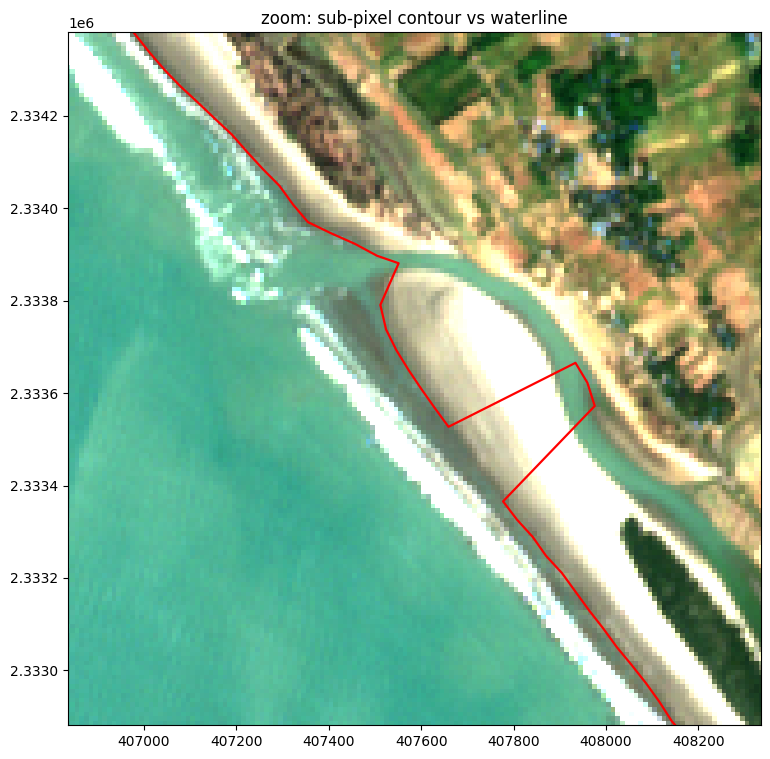

In [19]:
if 'line' in globals() and line is not None:
    mid = line.interpolate(0.5, normalized=True); half = 750
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(rgb_from_scene(sc), extent=extent, origin='upper')
    for ln in extract._as_line_list(line):
        xs, ys = ln.xy; ax.plot(xs, ys, '-', color='red', lw=1.6)
    ax.set_xlim(mid.x - half, mid.x + half); ax.set_ylim(mid.y - half, mid.y + half)
    ax.set_aspect('equal'); ax.set_title('zoom: sub-pixel contour vs waterline')
    plt.show()
else:
    print('Run the extraction cell first.')

## Batch extraction — Series A, then Series B

`extract_all` checkpoints to `outputs/shorelines/sds_scenes.geojson` after **every**
scene (resumes from it), frees each scene (`del`+`gc`), and prints per-scene
`rss`/`peak` RAM so you can confirm the footprint stays flat across the 829 Series B
scenes. Needs a classifier for every group the list uses — missing ones point you to
Notebook 03a (this notebook never trains).

In [ ]:
missing_A = [g for g in needed if not extract.model_exists(g)]
if missing_A:
    print('BLOCKED: Series A needs classifiers for', needed, '- missing:', missing_A)
    print('Run Notebook 03a to train the missing groups, then re-run this cell.')
else:
    settings = extract.default_settings()
    gdfA = extract.extract_all(annual, settings, classifiers=classifiers)   # per-scene RAM printed
    merged = extract.merge_annual(gdfA)
    os.makedirs(extract.SHORELINE_DIR, exist_ok=True)
    merged.to_file(extract.SDS_ANNUAL_PATH, driver='GeoJSON')
    print('Series A scenes:', len(gdfA), '-> merged segments:', len(merged))

# Series B (hundreds of scenes) — same call, once ready and TM/OLI/MSI all exist:
#   if not [g for g in ('TM','OLI','MSI') if not extract.model_exists(g)]:
#       gdfB = extract.extract_all(dense, extract.default_settings(), classifiers=classifiers)
# Push outputs/ to Drive + GitHub with save_outputs() (notebook 02).

## Benchmark / inter-sensor bias (deliverables)

Once transects + the 10 reference shorelines exist, select the operational index/
threshold and quantify cross-sensor offsets. Both load classifiers from Drive.

In [ ]:
# refs = gpd.read_file('data/reference_shorelines/<file>.geojson')  # image_id per line
# ref_rows = annual[annual['image_id'].isin(refs['image_id'])]
# ref_scenes = [extract.fetch_scene(r) for _, r in ref_rows.iterrows()]
# print(extract.benchmark_extraction(ref_scenes, refs, classifiers=classifiers))
# print(extract.intersensor_bias(gdfA))
print('Benchmark: provide data/reference_shorelines/ then uncomment above.')

## Operator artifacts (digitise in QGIS, upload via the GitHub web interface)

Upload under `data/` on GitHub, then `git pull` in the setup cell.

**`data/shoreline_search_zone.geojson`** — one polygon (EPSG:4326) enclosing every
plausible shoreline 1988–2025 (±300 m about the present shoreline, widening to
±800–1000 m within ~3 km of the Bakkhali and Naf mouths).

**`data/training_polygons.geojson`** — labelled polygons, `class` ∈ {`other`,
`sand`, `whitewater`, `water`}, each tagged with **`src_year`** and **`src_sensor`**
(the dry-year + sensor of the scene it was digitised over, e.g. 2023 / `S2`). ~6
scenes per sensor group (TM = L4/L5/L7, OLI = L8/L9, MSI = S2), spread along the
AOI; aim for ≥5,000 labelled pixels per class per group.

**`data/reference_shorelines/`** — 10 manually digitised validation shorelines
(LineStrings, EPSG:4326) with an `image_id` matching the scene, along the wet/dry
line. Used by `benchmark_extraction()`.

**`data/baseline.geojson`** — a LineString / MultiLineString landward of and roughly
parallel to the coast, **broken at the Naf and Bakkhali mouths** (transects are
cast per segment, never across a gap). Seaward direction is set automatically from
`config.SEAWARD_REFERENCE_LONLAT`.